In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df["country"].nunique()

167

In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
import math

def plot_all_histograms(df,title_prefix = ""):
    import math
    num_cols = df.select_dtypes(include = [np.number]).columns
    n_cols = 3 
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize = (5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols,1):
        plt.subplot(n_rows,n_cols,i)
        sns.histplot(df[col],kde=True,bins = 30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

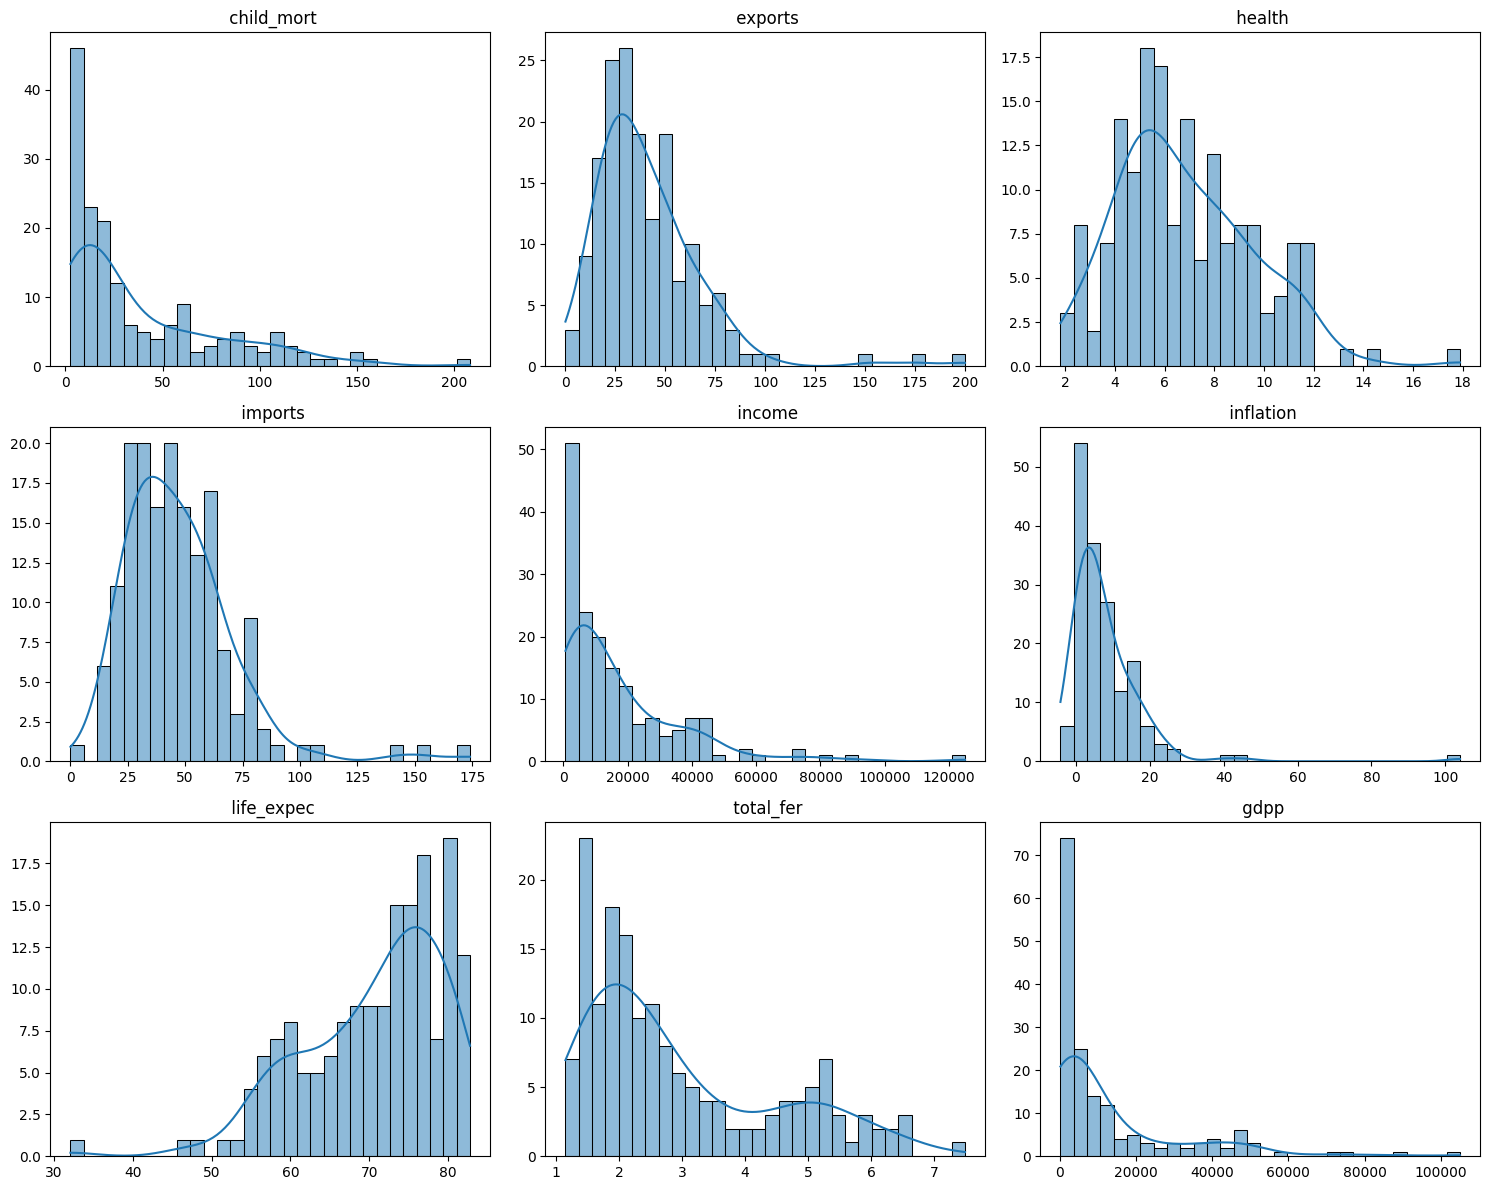

In [8]:
plot_all_histograms(df)

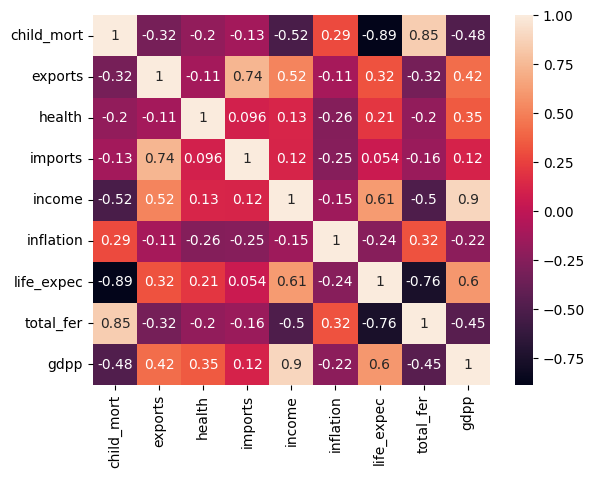

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot = True) 
plt.show()

In [10]:
df2 = df.drop("country",axis = 1)

In [11]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()

In [14]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [15]:
df2_columns = ['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp']

In [16]:
df2 = scaler.fit_transform(df2)

In [17]:
df2 = pd.DataFrame(df2,columns = df2_columns)

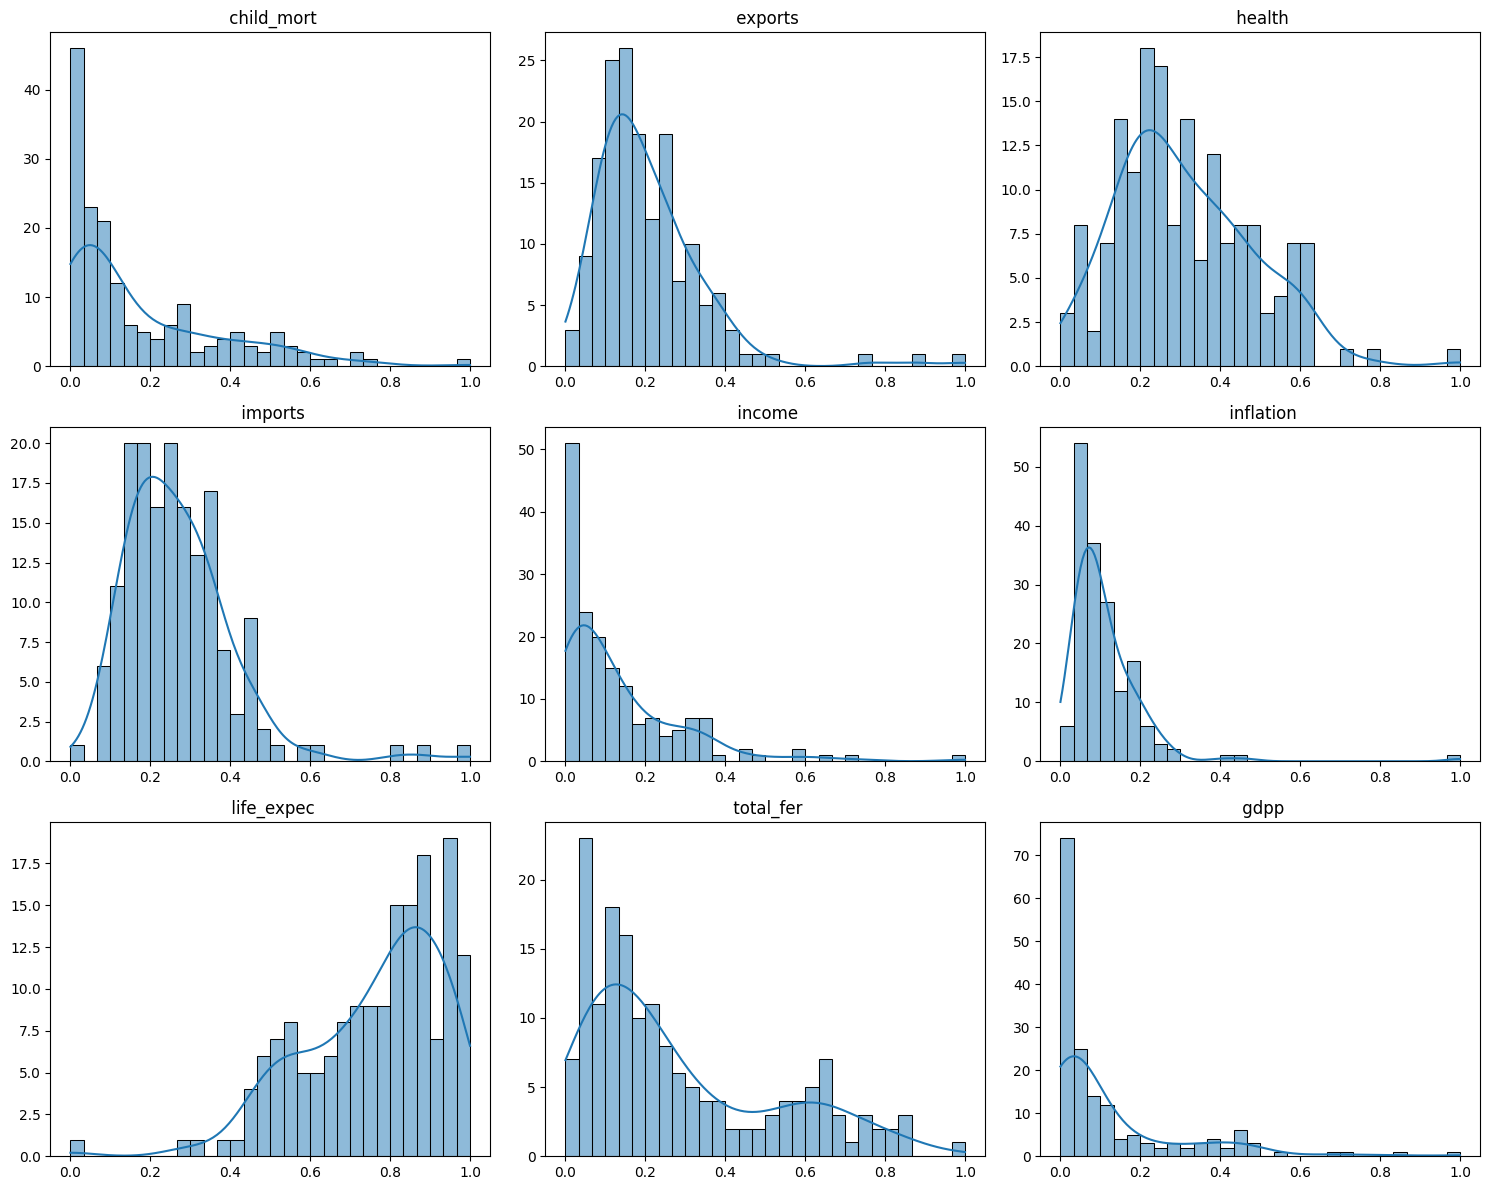

In [18]:
plot_all_histograms(df2)

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA()
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [21]:
pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [22]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

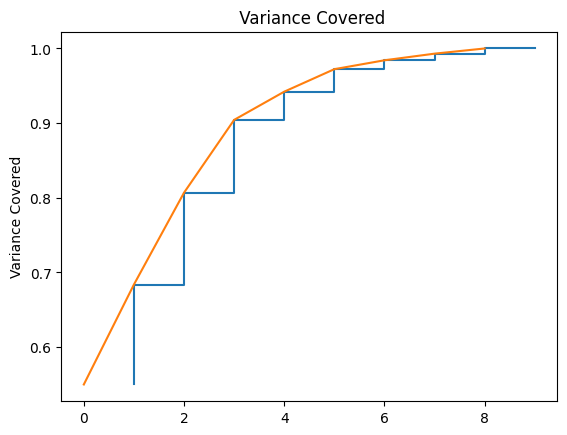

In [23]:
plt.step(list(range(1,10)) ,np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title(" Variance Covered")
plt.show()

In [24]:
pca_df2 = pca_df2.drop(columns = [3,4,5,6,7,8])

In [25]:
pca_df2.head()

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [27]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)

In [28]:
wcss

[34.53302925308179,
 17.68595420957709,
 11.270622261541494,
 9.598142275269286,
 7.3266244953103286,
 6.513353542642594,
 6.883108653200081,
 4.960182582694731,
 4.482785785667548,
 4.219238310206622]

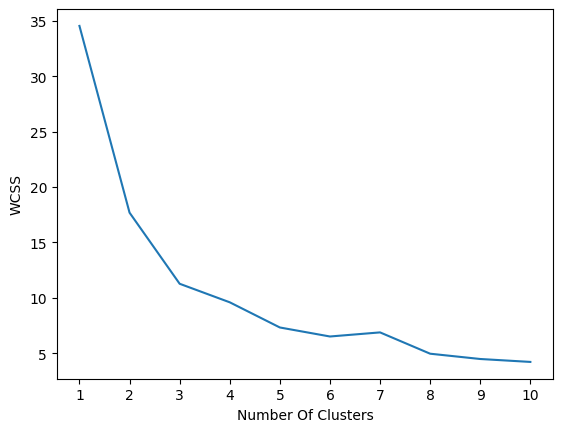

In [29]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number Of Clusters")
plt.ylabel("WCSS")
plt.show()

In [30]:
model = KMeans(n_clusters = 3, random_state = 42 )
model.fit(pca_df2)

KMeans(n_clusters=3, random_state=42)

In [31]:
labels = model.labels_

In [32]:
silhouette_score(pca_df2,labels)

np.float64(0.4386320345236685)

In [33]:
df["Class"] = labels

In [34]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


Text(0.5, 1.0, 'income vs Class')

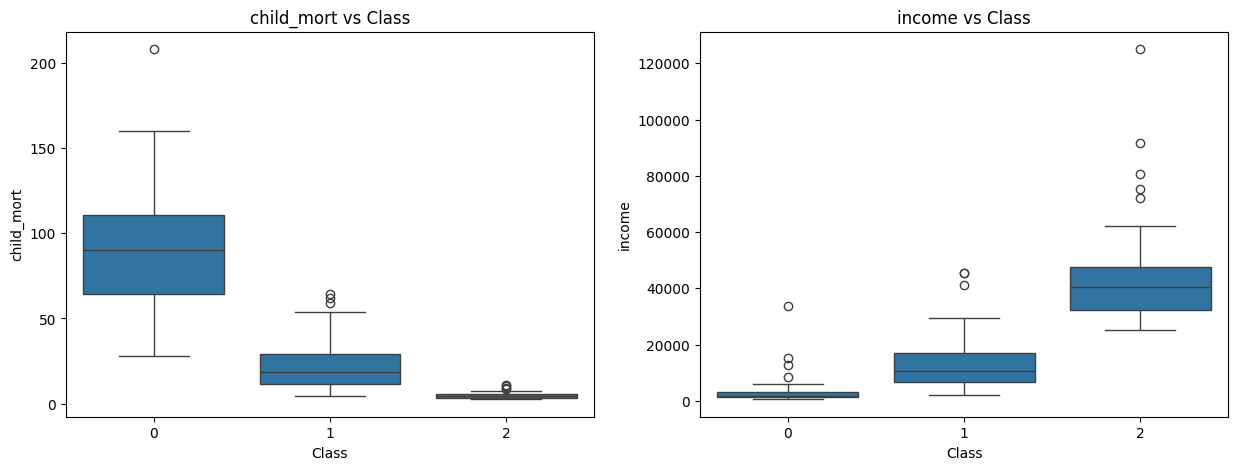

In [35]:
fig , ax = plt.subplots(nrows = 1 , ncols = 2 , figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(data = df, x = "Class",y = "child_mort")
plt.title("child_mort vs Class")

plt.subplot(1,2,2)
sns.boxplot(data = df, x = "Class",y = "income")
plt.title("income vs Class")

In [36]:
#  1 -> in between
# 0 -> budget needed
# 2 -> no budget needed

In [37]:
import plotly.express as px

In [38]:
pca_df2.insert(0,column = "Country",value = df["country"])

In [39]:
pca_df2["Class"] = labels

In [40]:
pca_df2.head()

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,0
1,Albania,-0.158474,-0.212092,-0.064189,1
2,Algeria,-0.003686,-0.135867,-0.134182,1
3,Angola,0.650235,0.275975,-0.142672,0
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,1


In [41]:
pca_df2.loc[pca_df2["Class"] == 0 , "Class"] = "Budget Needed"
pca_df2.loc[pca_df2["Class"] == 1 , "Class"] = "In Between"
pca_df2.loc[pca_df2["Class"] == 2 , "Class"] = "No Budget Needed"

/tmp/ipykernel_18/1116234445.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Budget Needed' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  pca_df2.loc[pca_df2["Class"] == 0 , "Class"] = "Budget Needed"


In [42]:
pca_df2.head()

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between


In [43]:
fig = px.choropleth(
    pca_df2[["Country","Class"]],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget by Country",
    color = "Class",
    color_discrete_map={
        "Budget Needed": "Red",
        "In Between": "Yellow",
        "No Budget Needed": "Green"
    })
fig.update_geos(fitbounds = "locations",visible = True)
fig.show()

In [44]:
import scipy.cluster.hierarchy as sch 

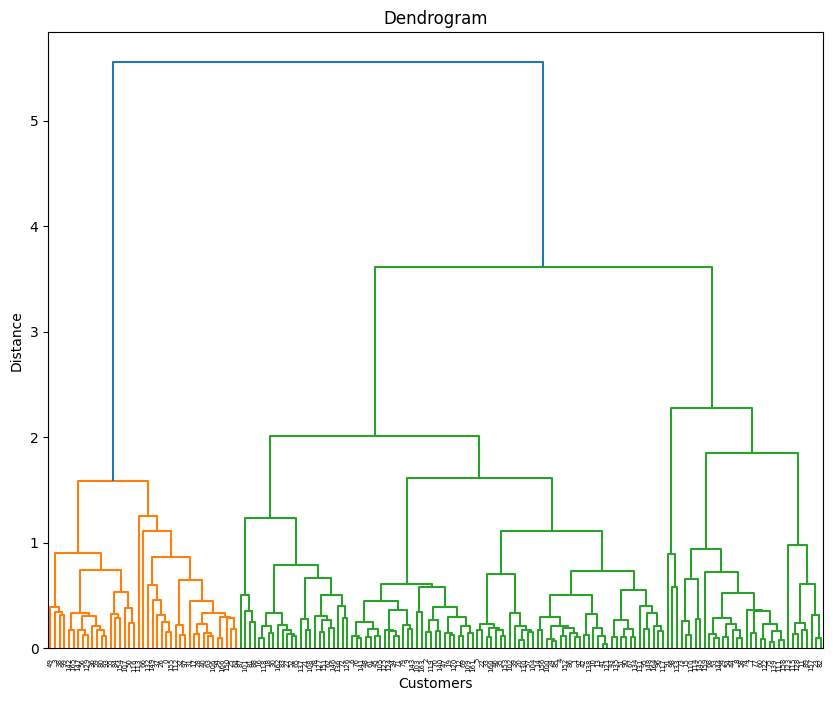

In [45]:
plt.figure(1,figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(df2,method = "ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [46]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score

In [47]:
hc = AgglomerativeClustering(n_clusters = 3)
y_hc1 = hc.fit_predict(df2)

sil = silhouette_score(df2,y_hc1)
db = davies_bouldin_score(df2,y_hc1)
ch = calinski_harabasz_score(df2,y_hc1)

print("Silhoute Score: ",sil)
print("Davies Bouldin Score: ",db)
print("Calinski Harabasz Score: ",ch)

Silhoute Score:  0.31627506051649634
Davies Bouldin Score:  1.1918513486135562
Calinski Harabasz Score:  86.47436128887398


In [48]:
pca_df2.head()

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,In Between
2,Algeria,-0.003686,-0.135867,-0.134182,In Between
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,In Between


In [49]:
pca_df2_clean = pca_df2.drop(["Country","Class"],axis = 1)

In [50]:
hc = AgglomerativeClustering(n_clusters = 3)
y_hc2 = hc.fit_predict(pca_df2_clean)

sil = silhouette_score(pca_df2_clean,y_hc2)
db = davies_bouldin_score(pca_df2_clean,y_hc2)
ch = calinski_harabasz_score(pca_df2_clean,y_hc2)

print("Silhoute Score: ",sil)
print("Davies Bouldin Score: ",db)
print("Calinski Harabasz Score: ",ch)

Silhoute Score:  0.39826966764598754
Davies Bouldin Score:  0.8591501962900453
Calinski Harabasz Score:  129.4320455489766


In [51]:
df_hc = df.drop("Class",axis = 1).copy()

In [52]:
df_hc["Class"] = y_hc2

In [53]:
df_hc.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


Text(0.5, 1.0, 'income vs Class')

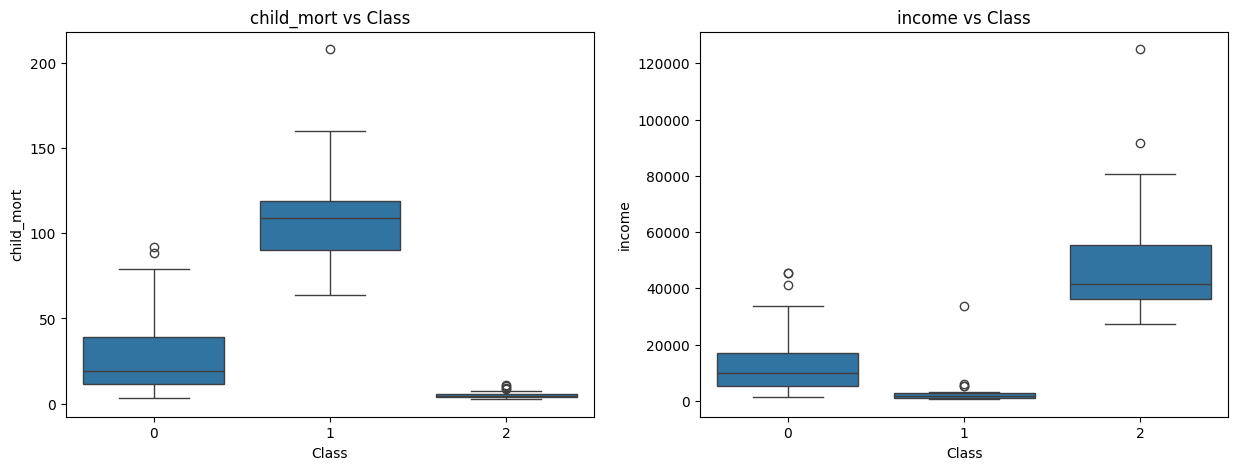

In [54]:
fig , ax = plt.subplots(nrows = 1 , ncols = 2 , figsize = (15,5))

plt.subplot(1,2,1)
sns.boxplot(data = df_hc, x = "Class",y = "child_mort")
plt.title("child_mort vs Class")

plt.subplot(1,2,2)
sns.boxplot(data = df_hc, x = "Class",y = "income")
plt.title("income vs Class")

In [55]:
df_hc = pca_df2.drop("Class",axis = 1).copy()
df_hc["Class"] = y_hc2
df_hc.head()

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,1
1,Albania,-0.158474,-0.212092,-0.064189,0
2,Algeria,-0.003686,-0.135867,-0.134182,0
3,Angola,0.650235,0.275975,-0.142672,1
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,0


In [56]:
df_hc.loc[df_hc["Class"] == 1 , "Class"] = "Budget Needed"
df_hc.loc[df_hc["Class"] == 0 , "Class"] = "In Between"
df_hc.loc[df_hc["Class"] == 2 , "Class"] = "No Budget Needed"

/tmp/ipykernel_18/2209983888.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Budget Needed' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



In [57]:
fig = px.choropleth(
    df_hc[["Country","Class"]],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget by Country",
    color = "Class",
    color_discrete_map={
        "Budget Needed": "Red",
        "In Between": "Yellow",
        "No Budget Needed": "Green"
    })
fig.update_geos(fitbounds = "locations",visible = True)
fig.show()

In [58]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


In [59]:
from sklearn.cluster import DBSCAN

In [60]:
dbscan = DBSCAN()
dbscan.fit(df2)
labels = dbscan.labels_
silhouette = silhouette_score(df2,labels)
print("silhouette score",silhouette)

silhouette score 0.4993958842751086


In [61]:
df_dbscan = df2.copy()
df_dbscan["Class"] = labels
df_dbscan["Class"].value_counts()

Class
 0    161
-1      6
Name: count, dtype: int64

In [62]:
from sklearn.cluster import HDBSCAN
hbscan = HDBSCAN()
hbscan.fit(df2)
labels_hdbscan = hbscan.labels_
silhouette = silhouette_score(df2,labels_hdbscan)
print("silhouette score",silhouette)

silhouette score 0.12498503688620508


In [63]:
df_hbscan = df2.copy()
df_hbscan["Class"] = labels_hdbscan
df_hbscan["Class"].value_counts()

Class
 1    65
-1    65
 0    21
 2    16
Name: count, dtype: int64